In [1]:

#  ПОДКЛЮЧЕНИЕ GOOGLE DRIVE И ЗАГРУЗКА ДАННЫХ


from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Подключение Google Drive

drive.mount("/content/drive")



# Пути проекта


PROJECT_DIR = Path(
    "/content/drive/MyDrive/ecommerce-product-analytics"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print()



# Проверка существования папки raw

if not RAW_DIR.exists():
    raise FileNotFoundError(
        f"Папка не найдена: {RAW_DIR}\n\n"
        "Проверь структуру Google Drive:\n"
        "MyDrive/ecommerce-product-analytics/data/raw/"
    )

print("✓ Папка с исходными данными найдена")



# Файлы датасета


file_names = {
    "olist_customers_dataset":
        "olist_customers_dataset.csv",

    "olist_geolocation_dataset":
        "olist_geolocation_dataset.csv",

    "olist_order_items_dataset":
        "olist_order_items_dataset.csv",

    "olist_order_payments_dataset":
        "olist_order_payments_dataset.csv",

    "olist_order_reviews_dataset":
        "olist_order_reviews_dataset.csv",

    "olist_orders_dataset":
        "olist_orders_dataset.csv",

    "olist_products_dataset":
        "olist_products_dataset.csv",

    "olist_sellers_dataset":
        "olist_sellers_dataset.csv",

    "product_category_name_translation":
        "product_category_name_translation.csv"
}



# Загрузка данных


dataframes = {}

print("\nЗагрузка данных:\n")

for dataset_name, file_name in file_names.items():

    file_path = RAW_DIR / file_name

    if not file_path.exists():

        if dataset_name == "olist_geolocation_dataset":
            print(
                f"⚠ {file_name} не найден — "
                "геолокационный датасет будет пропущен"
            )
            continue

        raise FileNotFoundError(
            f"Не найден обязательный файл:\n{file_path}"
        )

    try:
        df = pd.read_csv(file_path)

        dataframes[dataset_name] = df

        print(
            f"✓ {file_name:<45} "
            f"{df.shape[0]:>10,} строк × "
            f"{df.shape[1]:>3} столбцов"
        )

    except Exception as e:
        print(
            f"✗ Ошибка загрузки {file_name}: {e}"
        )
        raise



# Отдельные переменные



customers = dataframes["olist_customers_dataset"]

orders = dataframes["olist_orders_dataset"]

items = dataframes["olist_order_items_dataset"]

# дополнительный синоним
order_items = dataframes["olist_order_items_dataset"]

payments = dataframes["olist_order_payments_dataset"]

reviews = dataframes["olist_order_reviews_dataset"]

products = dataframes["olist_products_dataset"]

sellers = dataframes["olist_sellers_dataset"]

categories = dataframes[
    "product_category_name_translation"
]


if "olist_geolocation_dataset" in dataframes:
    geolocation = dataframes[
        "olist_geolocation_dataset"
    ]
else:
    geolocation = None



# Дополнительный словарь с короткими именами


tables = {
    "customers": customers,
    "orders": orders,
    "order_items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "categories": categories
}

if geolocation is not None:
    tables["geolocation"] = geolocation



# Проверка

print("\n" + "=" * 70)
print("ДАННЫЕ УСПЕШНО ЗАГРУЖЕНЫ")
print("=" * 70)

for name, df in dataframes.items():
    print(
        f"{name:<35} "
        f"{df.shape[0]:>10,} строк × "
        f"{df.shape[1]:>3} столбцов"
    )



#  Проверяем ключи словаря

print("\nКлючи dataframes:")

for key in dataframes.keys():
    print(" •", key)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/ecommerce-product-analytics
RAW_DIR: /content/drive/MyDrive/ecommerce-product-analytics/data/raw
PROCESSED_DIR: /content/drive/MyDrive/ecommerce-product-analytics/data/processed

✓ Папка с исходными данными найдена

Загрузка данных:

✓ olist_customers_dataset.csv                       99,441 строк ×   5 столбцов
✓ olist_geolocation_dataset.csv                  1,000,163 строк ×   5 столбцов
✓ olist_order_items_dataset.csv                    112,650 строк ×   7 столбцов
✓ olist_order_payments_dataset.csv                 103,886 строк ×   5 столбцов
✓ olist_order_reviews_dataset.csv                   99,224 строк ×   7 столбцов
✓ olist_orders_dataset.csv                          99,441 строк ×   8 столбцов
✓ olist_products_dataset.csv                        32,951 строк ×   9 столбцов
✓ olist_sellers_dataset.csv                          3,095 строк ×   4 столбцов
✓ product_category_name_translation.csv                 71 строк

In [10]:
# Общая информация по всем таблицам


# Создаем сводную таблицу
summary = []
for name, df in dataframes.items():
    summary.append({
        'Таблица': name,
        'Строки': df.shape[0],
        'Колонки': df.shape[1],
        'Память (MB)': df.memory_usage(deep=True).sum() / 1024**2,
        'Пропуски (%)': (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    })

summary_df = pd.DataFrame(summary)
summary_df.sort_values('Строки', ascending=False)

,Таблица,Строки,Колонки,Память (MB),Пропуски (%)
1,olist_geolocation_dataset,1000163,5,130.264880,0.000000
2,olist_order_items_dataset,112650,7,35.989649,0.000000
3,olist_order_payments_dataset,103886,5,16.229413,0.000000
0,olist_customers_dataset,99441,5,26.586405,0.000000
5,olist_orders_dataset,99441,8,52.937277,0.616949
4,olist_order_reviews_dataset,99224,7,39.124777,21.006295
6,olist_products_dataset,32951,9,6.296564,0.825468
7,olist_sellers_dataset,3095,4,0.588103,0.000000
8,product_category_name_translation,71,2,0.008999,0.000000


In [2]:
#  Детальный анализ каждой таблицы

def analyze_dataframe(df, name):
    """
    Функция для детального анализа качества данных
    """
    print(f"\n{'='*80}")
    print(f"АНАЛИЗ ТАБЛИЦЫ: {name}")
    print(f"{'='*80}")
    print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")

    #  Анализ типов данных
    print("\n--- 3.1 ТИПЫ ДАННЫХ ---")
    dtypes_df = pd.DataFrame({
        'Колонка': df.dtypes.index,
        'Тип': df.dtypes.values,
        'Уникальных': [df[col].nunique() for col in df.columns],
        'Пропуски': df.isnull().sum().values,
        'Пропуски (%)': (df.isnull().sum() / len(df) * 100).values
    })
    print(dtypes_df.to_string(index=False))

    #  Анализ пропусков
    print("\n--- 3.2 АНАЛИЗ ПРОПУСКОВ ---")
    if df.isnull().sum().sum() > 0:
        missing_cols = df.isnull().sum()[df.isnull().sum() > 0]
        for col, count in missing_cols.items():
            pct = (count / len(df)) * 100
            print(f"  • {col}: {count} пропусков ({pct:.2f}%)")
    else:
        print("  ✓ Пропусков нет")

    #  Анализ дубликатов
    print("\n--- 3.3 АНАЛИЗ ДУБЛИКАТОВ ---")
    duplicates = df.duplicated().sum()
    print(f"  • Полных дубликатов строк: {duplicates}")

    # Проверка первичных ключей
    id_columns = [col for col in df.columns if 'id' in col.lower()]
    for col in id_columns:
        if df[col].nunique() < len(df):
            dup_count = len(df) - df[col].nunique()
            print(f"  • {col}: {dup_count} дубликатов ({dup_count/len(df)*100:.2f}%)")
        else:
            print(f"  • {col}: Уникальных значений {df[col].nunique()} - все уникальны ✓")

    # Статистика числовых колонок
    print("\n--- 3.4 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().to_string())

        # Проверка отрицательных значений
        for col in numeric_cols:
            neg_count = (df[col] < 0).sum()
            if neg_count > 0:
                print(f"  ⚠ {col}: {neg_count} отрицательных значений")
    else:
        print("  Числовых колонок нет")

    #  Анализ строковых колонок
    print("\n 3.5 АНАЛИЗ СТРОКОВЫХ КОЛОНОК ")
    string_cols = df.select_dtypes(include=['object']).columns
    for col in string_cols[:3]:
        print(f"\n  {col}:")
        print(f"    Уникальных значений: {df[col].nunique()}")
        print(f"    Пустых строк: {(df[col] == '').sum()}")
        if df[col].nunique() <= 10:
            print(f"    • Значения: {df[col].value_counts().head(5).to_dict()}")

    return {
        'name': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'missing_pct': (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100,
        'duplicates': duplicates,
        'numeric_cols': len(numeric_cols)
    }
# Анализируем каждую таблицу
analysis_results = []
for name, df in dataframes.items():
    result = analyze_dataframe(df, name)
    analysis_results.append(result)


АНАЛИЗ ТАБЛИЦЫ: olist_customers_dataset
Размер: 99441 строк × 5 колонок

--- 3.1 ТИПЫ ДАННЫХ ---
                 Колонка    Тип  Уникальных  Пропуски  Пропуски (%)
             customer_id object       99441         0           0.0
      customer_unique_id object       96096         0           0.0
customer_zip_code_prefix  int64       14994         0           0.0
           customer_city object        4119         0           0.0
          customer_state object          27         0           0.0

--- 3.2 АНАЛИЗ ПРОПУСКОВ ---
  ✓ Пропусков нет

--- 3.3 АНАЛИЗ ДУБЛИКАТОВ ---
  • Полных дубликатов строк: 0
  • customer_id: Уникальных значений 99441 - все уникальны ✓
  • customer_unique_id: 3345 дубликатов (3.36%)

--- 3.4 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК ---
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%       

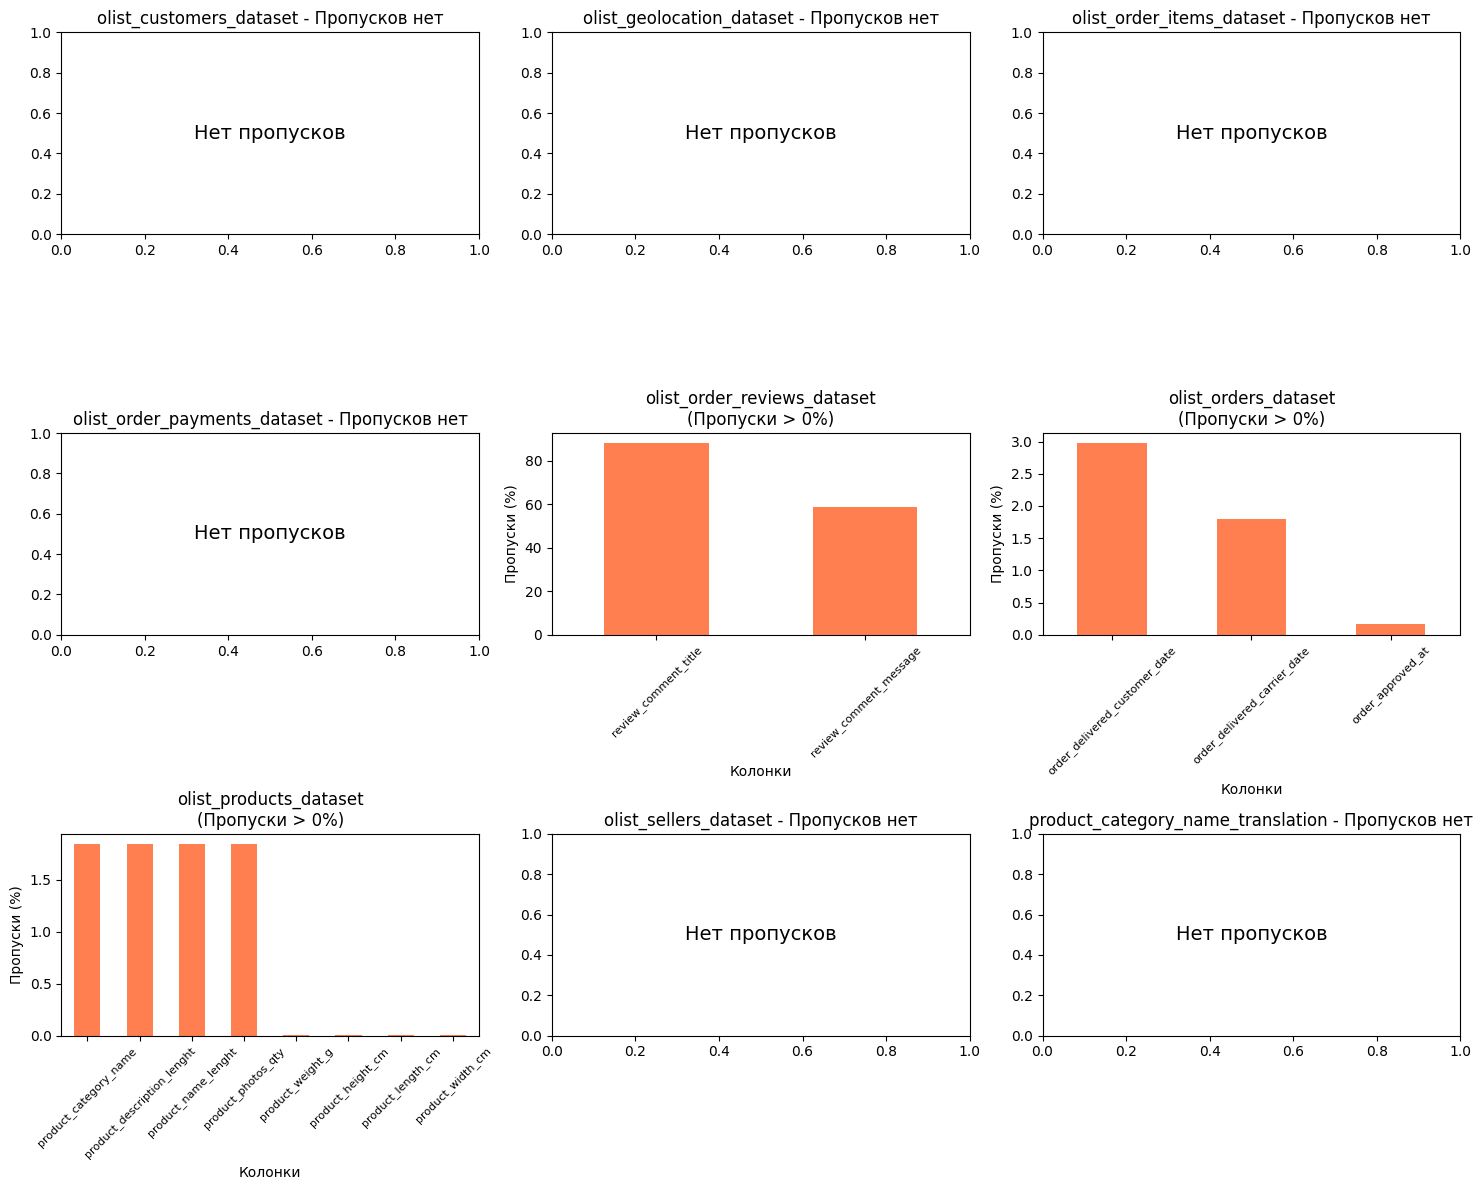

In [3]:
#  Визуализация пропусков


def plot_missing_values(df_dict):
    """
    Визуализация пропусков в каждой таблице
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (name, df) in enumerate(df_dict.items()):
        if idx < 9:
            missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
            missing_pct = missing_pct[missing_pct > 0]

            if len(missing_pct) > 0:
                missing_pct.plot(kind='bar', ax=axes[idx], color='coral')
                axes[idx].set_title(f'{name}\n(Пропуски > 0%)')
                axes[idx].set_xlabel('Колонки')
                axes[idx].set_ylabel('Пропуски (%)')
                axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
            else:
                axes[idx].text(0.5, 0.5, 'Нет пропусков',
                             horizontalalignment='center',
                             verticalalignment='center',
                             transform=axes[idx].transAxes, fontsize=14)
                axes[idx].set_title(f'{name} - Пропусков нет')

    plt.tight_layout()
    plt.show()

plot_missing_values(dataframes)

In [4]:
#  Анализ целостности связей

# %%
print("\n" + "="*80)
print("АНАЛИЗ ЦЕЛОСТНОСТИ СВЯЗЕЙ МЕЖДУ ТАБЛИЦАМИ")
print("="*80)


if 'olist_orders_dataset' in dataframes and 'olist_customers_dataset' in dataframes:
    orders = dataframes['olist_orders_dataset']
    customers = dataframes['olist_customers_dataset']

    orders_customers = set(orders['customer_id'].unique())
    customers_ids = set(customers['customer_id'].unique())

    missing_customers = orders_customers - customers_ids

    print(f"\n--- Связь Заказы -> Клиенты ---")
    print(f"  • Уникальных customer_id в заказах: {len(orders_customers)}")
    print(f"  • Уникальных customer_id в клиентах: {len(customers_ids)}")
    print(f"  • customer_id из заказов, отсутствующих в клиентах: {len(missing_customers)}")

    if len(missing_customers) == 0:
        print("  ✓ Все customer_id из заказов присутствуют в таблице клиентов")
    else:
        print(f"  ⚠ Найдены customer_id без записей в таблице клиентов")


if 'olist_order_items_dataset' in dataframes and 'olist_orders_dataset' in dataframes:
    items = dataframes['olist_order_items_dataset']
    orders = dataframes['olist_orders_dataset']

    items_orders = set(items['order_id'].unique())
    orders_ids = set(orders['order_id'].unique())

    missing_orders = items_orders - orders_ids

    print(f"\n--- Связь Товары -> Заказы ---")
    print(f"  • Уникальных order_id в товарах: {len(items_orders)}")
    print(f"  • Уникальных order_id в заказах: {len(orders_ids)}")
    print(f"  • order_id из товаров, отсутствующих в заказах: {len(missing_orders)}")

    if len(missing_orders) == 0:
        print("  ✓ Все order_id из товаров присутствуют в таблице заказов")
    else:
        print(f"  ⚠ Найдены order_id без записей в таблице заказов")

# Проверяем, что все order_id из платежей есть в заказах
if 'olist_order_payments_dataset' in dataframes and 'olist_orders_dataset' in dataframes:
    payments = dataframes['olist_order_payments_dataset']
    orders = dataframes['olist_orders_dataset']

    payments_orders = set(payments['order_id'].unique())
    orders_ids = set(orders['order_id'].unique())

    missing_payments = payments_orders - orders_ids

    print(f"\n--- Связь Платежи -> Заказы ---")
    print(f"  • Уникальных order_id в платежах: {len(payments_orders)}")
    print(f"  • Уникальных order_id в заказах: {len(orders_ids)}")
    print(f"  • order_id из платежей, отсутствующих в заказах: {len(missing_payments)}")

    if len(missing_payments) == 0:
        print("  ✓ Все order_id из платежей присутствуют в таблице заказов")
    else:
        print(f"  ⚠ Найдены order_id без записей в таблице заказов")

# Проверяем, что все product_id из товаров есть в продуктах
if 'olist_order_items_dataset' in dataframes and 'olist_products_dataset' in dataframes:
    items = dataframes['olist_order_items_dataset']
    products = dataframes['olist_products_dataset']

    items_products = set(items['product_id'].unique())
    products_ids = set(products['product_id'].unique())

    missing_products = items_products - products_ids

    print(f"\n--- Связь Товары в заказе -> Продукты ---")
    print(f"  • Уникальных product_id в товарах заказа: {len(items_products)}")
    print(f"  • Уникальных product_id в продуктах: {len(products_ids)}")
    print(f"  • product_id из заказов, отсутствующих в продуктах: {len(missing_products)}")

    if len(missing_products) == 0:
        print("  ✓ Все product_id из товаров заказа присутствуют в таблице продуктов")
    else:
        print(f"  ⚠ Найдены product_id без записей в таблице продуктов")


АНАЛИЗ ЦЕЛОСТНОСТИ СВЯЗЕЙ МЕЖДУ ТАБЛИЦАМИ

--- Связь Заказы -> Клиенты ---
  • Уникальных customer_id в заказах: 99441
  • Уникальных customer_id в клиентах: 99441
  • customer_id из заказов, отсутствующих в клиентах: 0
  ✓ Все customer_id из заказов присутствуют в таблице клиентов

--- Связь Товары -> Заказы ---
  • Уникальных order_id в товарах: 98666
  • Уникальных order_id в заказах: 99441
  • order_id из товаров, отсутствующих в заказах: 0
  ✓ Все order_id из товаров присутствуют в таблице заказов

--- Связь Платежи -> Заказы ---
  • Уникальных order_id в платежах: 99440
  • Уникальных order_id в заказах: 99441
  • order_id из платежей, отсутствующих в заказах: 0
  ✓ Все order_id из платежей присутствуют в таблице заказов

--- Связь Товары в заказе -> Продукты ---
  • Уникальных product_id в товарах заказа: 32951
  • Уникальных product_id в продуктах: 32951
  • product_id из заказов, отсутствующих в продуктах: 0
  ✓ Все product_id из товаров заказа присутствуют в таблице продукто

In [5]:
# Особый анализ для ключевых колонок


if 'product_category_name_translation' in dataframes and 'olist_products_dataset' in dataframes:
    trans = dataframes['product_category_name_translation']
    products = dataframes['olist_products_dataset']

    print("\n" + "="*80)
    print("АНАЛИЗ КАТЕГОРИЙ ТОВАРОВ")
    print("="*80)

    # Проверяем, все ли категории переведены
    categories = set(products['product_category_name'].unique())
    translated = set(trans['product_category_name'].unique())

    not_translated = categories - translated

    print(f"  • Всего уникальных категорий: {len(categories)}")
    print(f"  • Переведено категорий: {len(translated)}")
    print(f"  • Не переведено категорий: {len(not_translated)}")

    if len(not_translated) > 0:
        print(f"  ⚠ Категории без перевода: {list(not_translated)[:10]}")

# Анализ статусов заказов
if 'olist_orders_dataset' in dataframes:
    orders = dataframes['olist_orders_dataset']
    print("\n" + "="*80)
    print("АНАЛИЗ СТАТУСОВ ЗАКАЗОВ")
    print("="*80)
    print(orders['order_status'].value_counts())

# Анализ оценок
if 'olist_order_reviews_dataset' in dataframes:
    reviews = dataframes['olist_order_reviews_dataset']
    print("\n" + "="*80)
    print("АНАЛИЗ ОЦЕНОК")
    print("="*80)
    print(reviews['review_score'].value_counts().sort_index())

    # Проверяем наличие текстовых отзывов
    non_empty_reviews = reviews['review_comment_message'].notna().sum()
    print(f"\n  • Отзывов с комментариями: {non_empty_reviews}")
    print(f"  • Отзывов без комментариев: {reviews['review_comment_message'].isna().sum()}")


АНАЛИЗ КАТЕГОРИЙ ТОВАРОВ
  • Всего уникальных категорий: 74
  • Переведено категорий: 71
  • Не переведено категорий: 3
  ⚠ Категории без перевода: ['portateis_cozinha_e_preparadores_de_alimentos', nan, 'pc_gamer']

АНАЛИЗ СТАТУСОВ ЗАКАЗОВ
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

АНАЛИЗ ОЦЕНОК
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

  • Отзывов с комментариями: 40977
  • Отзывов без комментариев: 58247


In [6]:
#  Выявление аномалий в числовых данных


def detect_outliers(df, column, method='iqr'):
    """
    Обнаружение выбросов в числовых колонках
    """
    if method == 'iqr':
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        return outliers, lower_bound, upper_bound
    return None, None, None

# Анализ выбросов для цен
if 'olist_order_items_dataset' in dataframes:
    items = dataframes['olist_order_items_dataset']

    print("\n" + "="*80)
    print("АНАЛИЗ ВЫБРОСОВ В ЧИСЛОВЫХ ДАННЫХ")
    print("="*80)

    for col in ['price', 'freight_value']:
        if col in items.columns:
            outliers, lower, upper = detect_outliers(items, col)
            print(f"\n--- {col.upper()} ---")
            print(f"  • Min: {items[col].min():.2f}")
            print(f"  • Max: {items[col].max():.2f}")
            print(f"  • Mean: {items[col].mean():.2f}")
            print(f"  • Median: {items[col].median():.2f}")
            print(f"  • Std: {items[col].std():.2f}")
            print(f"  • Количество выбросов (IQR): {len(outliers)}")
            if len(outliers) > 0:
                print(f"  • % выбросов: {len(outliers)/len(items)*100:.2f}%")



АНАЛИЗ ВЫБРОСОВ В ЧИСЛОВЫХ ДАННЫХ

--- PRICE ---
  • Min: 0.85
  • Max: 6735.00
  • Mean: 120.65
  • Median: 74.99
  • Std: 183.63
  • Количество выбросов (IQR): 8427
  • % выбросов: 7.48%

--- FREIGHT_VALUE ---
  • Min: 0.00
  • Max: 409.68
  • Mean: 19.99
  • Median: 16.26
  • Std: 15.81
  • Количество выбросов (IQR): 12134
  • % выбросов: 10.77%


In [7]:
# Итоговый отчет по качеству данных

# %%
print("\n" + "="*80)
print("ИТОГОВЫЙ ОТЧЕТ ПО КАЧЕСТВУ ДАННЫХ")
print("="*80)

# Создаем итоговую таблицу
final_summary = []
for name, df in dataframes.items():
    final_summary.append({
        'Таблица': name,
        'Строки': df.shape[0],
        'Колонки': df.shape[1],
        'Пропуски (%)': (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100,
        'Дубликаты': df.duplicated().sum(),
        'Память (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })

final_df = pd.DataFrame(final_summary)
print(final_df.round(2).to_string(index=False))

# Вывод основных проблем и рекомендаций
print("\n" + "="*80)
print("ВЫЯВЛЕННЫЕ ПРОБЛЕМЫ И РЕКОМЕНДАЦИИ")
print("="*80)

issues = []

# Проверяем пропуски
for name, df in dataframes.items():
    missing_pct = (df.isnull().sum() / len(df) * 100)
    high_missing = missing_pct[missing_pct > 20]
    if len(high_missing) > 0:
        for col, pct in high_missing.items():
            issues.append(f" {name}: {col} имеет {pct:.1f}% пропусков")

# Проверяем отрицательные значения
if 'olist_order_items_dataset' in dataframes:
    items = dataframes['olist_order_items_dataset']
    for col in ['price', 'freight_value']:
        neg = (items[col] < 0).sum()
        if neg > 0:
            issues.append(f" olist_order_items_dataset: {col} содержит {neg} отрицательных значений")

if issues:
    for issue in issues:
        print(f"  • {issue}")
else:
    print("  ✓ Качество данных хорошее, критических проблем не обнаружено")

print("\n" + "="*80)
print("АНАЛИЗ КАЧЕСТВА ДАННЫХ ЗАВЕРШЕН")
print("="*80)



ИТОГОВЫЙ ОТЧЕТ ПО КАЧЕСТВУ ДАННЫХ
                          Таблица  Строки  Колонки  Пропуски (%)  Дубликаты  Память (MB)
          olist_customers_dataset   99441        5          0.00          0        26.59
        olist_geolocation_dataset 1000163        5          0.00     261831       130.26
        olist_order_items_dataset  112650        7          0.00          0        35.99
     olist_order_payments_dataset  103886        5          0.00          0        16.23
      olist_order_reviews_dataset   99224        7         21.01          0        39.12
             olist_orders_dataset   99441        8          0.62          0        52.94
           olist_products_dataset   32951        9          0.83          0         6.30
            olist_sellers_dataset    3095        4          0.00          0         0.59
product_category_name_translation      71        2          0.00          0         0.01

ВЫЯВЛЕННЫЕ ПРОБЛЕМЫ И РЕКОМЕНДАЦИИ
  • ⚠ olist_order_reviews_dataset: revi

In [9]:
=
#  СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА КАЧЕСТВА ДАННЫХ


from pathlib import Path

# Папка для документации проекта
DOCS_DIR = PROJECT_DIR / "docs"

# Создаем папку, если ее еще нет
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# Полный путь к отчету
QUALITY_REPORT_PATH = DOCS_DIR / "quality_issues.txt"


# Сохраняем основные проблемы и рекомендации
with open(QUALITY_REPORT_PATH, "w", encoding="utf-8") as f:

    f.write("DATA QUALITY ISSUES REPORT\n")
    f.write("=" * 50 + "\n\n")


    # Выявленные проблемы


    f.write("ISSUES:\n")
    f.write("-" * 20 + "\n")

    if issues:
        for issue in issues:
            f.write(f"- {issue}\n")
    else:
        f.write("- Критических проблем качества данных не обнаружено\n")



    # Рекомендации


    f.write("\nRECOMMENDATIONS:\n")
    f.write("-" * 20 + "\n")

    f.write(
        "1. Проанализировать пропуски и определить, "
        "какие из них являются допустимыми по бизнес-логике.\n"
    )

    f.write(
        "2. Проверить отрицательные и аномальные значения "
        "в price и freight_value.\n"
    )

    f.write(
        "3. Убедиться в целостности внешних ключей "
        "между связанными таблицами.\n"
    )

    f.write(
        "4. Привести даты и числовые поля "
        "к корректным типам данных.\n"
    )

    f.write(
        "5. Проверить дубликаты с учетом гранулярности "
        "каждой таблицы.\n"
    )

    f.write(
        "6. Не удалять пропуски автоматически: "
        "для review_comment_title и review_comment_message "
        "отсутствие текста может быть допустимым.\n"
    )


print("\n✓ Отчет сохранен:")
print(QUALITY_REPORT_PATH)


✓ Отчет сохранен:
/content/drive/MyDrive/ecommerce-product-analytics/docs/quality_issues.txt
